# 🇧🇯 Prédiction Prospective — Bénin
### Anticipation des crises, révoltes et instabilités socio-politiques

> **Objectif** : Utiliser les données GDELT historiques pour construire un système de prédiction
> du niveau de risque au Bénin à horizon 1, 4 et 12 semaines.
>
> **Approches** : Prédiction de séries temporelles (Prophet), scoring de risque composite,
> alertes précoces (Early Warning System), et simulation de scénarios.

---

## 0. Setup & Imports

In [8]:
# Installation des dépendances supplémentaires
!pip install prophet shap plotly ruptures nbformat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import pickle
import warnings
import json
from pathlib import Path

# ML & Stats
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier

# Séries temporelles
from prophet import Prophet
import ruptures as rpt

# Explicabilité
import shap

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# --- Config visuelle ---
COLORS = {
    'primary':   '#E91E8C',
    'secondary': '#7B2FBE',
    'accent':    '#00D4AA',
    'dark':      '#1A1A2E',
    'danger':    '#FF3B3B',
    'warning':   '#FF9500',
    'safe':      '#34C759'
}
PALETTE = ['#E91E8C','#7B2FBE','#00D4AA','#FF6B35','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})

# --- Chemins ---
BASE      = Path('..')
DATA_PROC = BASE / 'data' / 'processed'
MODELS    = BASE / 'models'
OUTPUTS   = BASE / 'outputs'
OUTPUTS.mkdir(parents=True, exist_ok=True)

print('✅ Environnement prêt')

## 1. Chargement des données & modèles existants

In [20]:
# Charger les données enrichies (avec proba_conflict du notebook précédent)
df = pd.read_csv('/content/data/proccessed/gdelt_models_data.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

# Charger les modèles sauvegardés
with open('/content/models/models_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

model_rf      = bundle['rf']
model_xgboost = bundle['xgboost']
scaler        = bundle['scaler']
features      = bundle['feat']

print(f'📅 Période : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'📊 Événements : {len(df):,}')
print(f'⚠️  Taux de conflits : {df["IsConflict"].mean()*100:.1f}%')
df.head(3)

📅 Période : 2025-01-01 → 2025-12-31
📊 Événements : 8,000
⚠️  Taux de conflits : 22.7%


,SQLDATE,date,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,EventCode,EventLabel,QuadClass,GoldsteinScale,...,GKG_ThemeEnviro,GKG_ToneGap,GKG_EmotionIntensity,ToneCategory,GoldsteinBin,cluster_kmeans,PCA1,PCA2,cluster_dbscan,proba_conflict
0,20250101,2025-01-01,Syndicat UNSTB,BN,Gouvernement du Benin,BN,120,Menace,3,-3.59,...,1,-3.47,7.334,Negatif,Destabilisant,0,0.316735,-1.716037,0,0.999054
1,20250101,2025-01-01,Presidence de la Republique,BN,Assemblee Nationale,BN,112,Refus requete,3,-4.22,...,1,1.25,9.405,Tres negatif,Destabilisant,1,1.775264,-2.419827,-1,0.999884
2,20250101,2025-01-01,Assemblee Nationale,BN,Syndicat UNSTB,BN,130,Protestation,3,-0.87,...,1,-5.44,7.659,Positif,Leg. negatif,1,0.850519,0.118250,0,0.019777


## 2. Construction de l'Indice de Risque Composite (IRC)

> L'IRC agrège plusieurs signaux faibles en un score hebdomadaire unique,
> sur une échelle de 0 (calme) à 100 (crise imminente).

In [21]:
# --- Agrégation hebdomadaire ---
df['week'] = df['date'].dt.to_period('W')

agg_dict = {
    'EventCode':       'count',
    'GoldsteinScale':  'mean',
    'AvgTone':         'mean',
    'NumMentions':     'sum',
    'NumArticles':     'sum',
    'IsConflict':      'mean',
    'proba_conflict':  'mean',
}

# Colonnes optionnelles
for col in ['IsNorthBenin', 'MediaWeight', 'GoldsteinNorm', 'ToneNorm']:
    if col in df.columns:
        agg_dict[col] = 'mean'

weekly = df.groupby('week').agg(agg_dict).reset_index()
weekly.columns = ['week', 'EventCount', 'Goldstein_moy', 'Tone_moy',
                   'TotalMentions', 'TotalArticles', 'ConflictRate',
                   'ProbaConflict_moy'] + \
                  [c for c in ['IsNorthBenin', 'MediaWeight', 'GoldsteinNorm', 'ToneNorm'] if c in df.columns]

weekly['date_dt'] = weekly['week'].dt.to_timestamp()

# --- Construction de l'IRC ---
def normalize_01(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Composantes (poids ajustables)
weekly['C1_Conflictualite']  = normalize_01(weekly['ConflictRate'])       # Taux de conflits brut
weekly['C2_Proba_ML']        = normalize_01(weekly['ProbaConflict_moy'])  # Signal XGBoost
weekly['C3_Goldstein_inv']   = normalize_01(-weekly['Goldstein_moy'])     # Score Goldstein inversé
weekly['C4_Tone_negatif']    = normalize_01(-weekly['Tone_moy'])          # Ton négatif
weekly['C5_Volume_media']    = normalize_01(weekly['TotalArticles'])       # Couverture médiatique

# Pondération
POIDS = {
    'C1_Conflictualite': 0.30,
    'C2_Proba_ML':       0.30,
    'C3_Goldstein_inv':  0.20,
    'C4_Tone_negatif':   0.10,
    'C5_Volume_media':   0.10,
}

weekly['IRC'] = sum(weekly[c] * w for c, w in POIDS.items()) * 100

# Niveau de risque
def niveau_risque(score):
    if score >= 70: return 'CRITIQUE'
    elif score >= 50: return 'ÉLEVÉ'
    elif score >= 30: return 'MODÉRÉ'
    else: return 'FAIBLE'

weekly['NiveauRisque'] = weekly['IRC'].apply(niveau_risque)

print('📊 Distribution des niveaux de risque historiques :')
print(weekly['NiveauRisque'].value_counts())
print(f'\n📈 IRC moyen : {weekly["IRC"].mean():.1f} / 100')
print(f'🔴 IRC max   : {weekly["IRC"].max():.1f} (semaine {weekly.loc[weekly["IRC"].idxmax(), "week"]})')

📊 Distribution des niveaux de risque historiques :
NiveauRisque
ÉLEVÉ       24
MODÉRÉ      18
CRITIQUE     6
FAIBLE       5
Name: count, dtype: int64

📈 IRC moyen : 51.1 / 100
🔴 IRC max   : 95.4 (semaine 2025-03-24/2025-03-30)


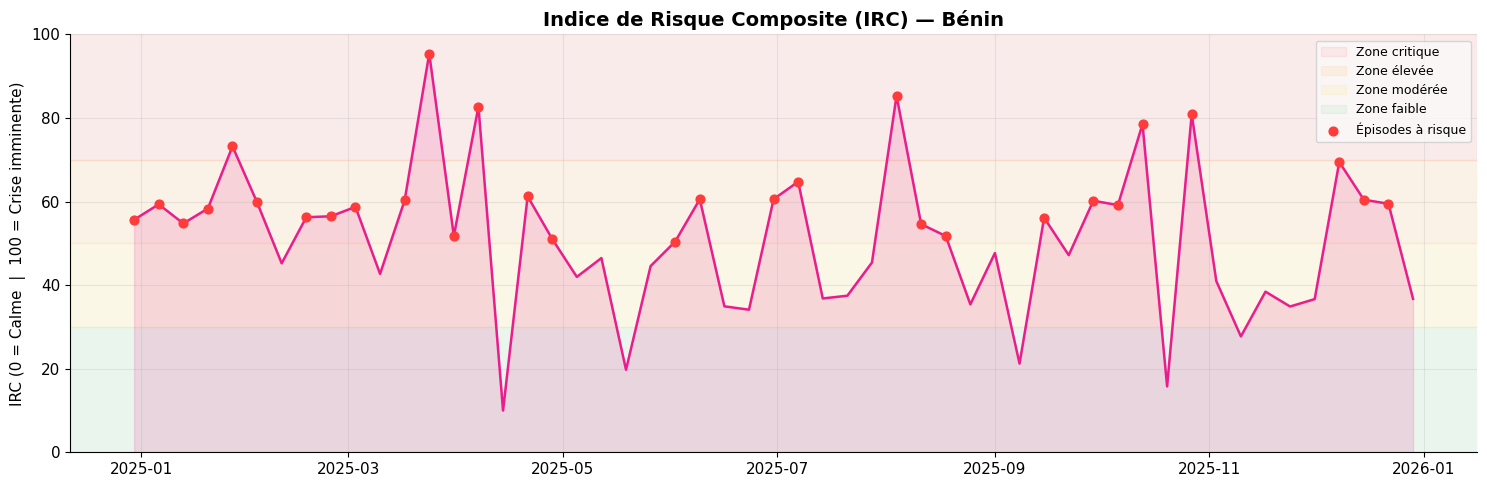

💾 Sauvegardé : outputs/irc_historique.png


In [24]:
# --- Visualisation de l'IRC historique ---
color_map = {'CRITIQUE': COLORS['danger'], 'ÉLEVÉ': COLORS['warning'],
             'MODÉRÉ': '#FFD700', 'FAIBLE': COLORS['safe']}

fig, ax = plt.subplots(figsize=(15, 5))

# Zones de risque
ax.axhspan(70, 100, alpha=0.08, color=COLORS['danger'],  label='Zone critique')
ax.axhspan(50,  70, alpha=0.08, color=COLORS['warning'], label='Zone élevée')
ax.axhspan(30,  50, alpha=0.08, color='gold',            label='Zone modérée')
ax.axhspan(0,   30, alpha=0.08, color=COLORS['safe'],    label='Zone faible')

# Courbe IRC
ax.plot(weekly['date_dt'], weekly['IRC'], color=COLORS['primary'], lw=1.8, zorder=3)
ax.fill_between(weekly['date_dt'], weekly['IRC'], alpha=0.15, color=COLORS['primary'])

# Points de risque élevé
high = weekly[weekly['IRC'] >= 50]
ax.scatter(high['date_dt'], high['IRC'], color=COLORS['danger'], s=40, zorder=5, label='Épisodes à risque')

ax.set_ylim(0, 100)
ax.set_title('Indice de Risque Composite (IRC) — Bénin', fontsize=14, fontweight='bold')
ax.set_ylabel('IRC (0 = Calme  |  100 = Crise imminente)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
# plt.savefig(OUTPUTS / 'irc_historique.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : outputs/irc_historique.png')

## 3. Détection des pics de crise passés (Changepoint)

> On vérifie que nos ruptures historiques coïncident avec des événements réels
> (élections, manifestations, crises politiques au Bénin).

🔍 0 ruptures détectées dans l'IRC


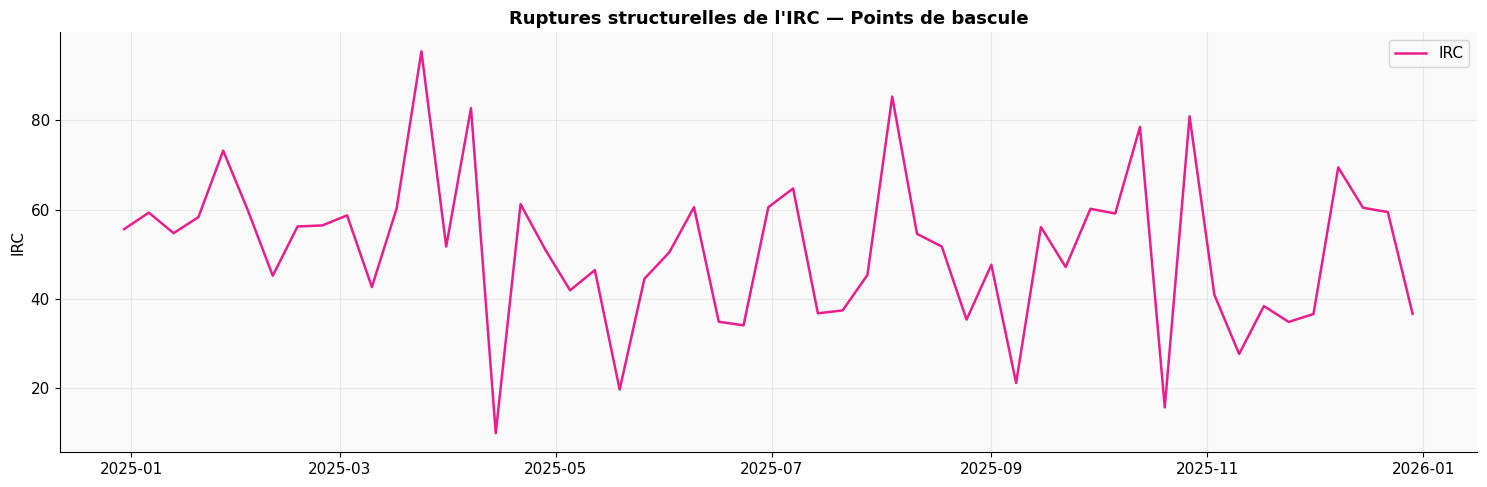


🔴 Top 10 semaines les plus à risque :
      Date       IRC   Niveau Taux conflit  Ton moyen  Goldstein moyen
2025-03-24 95.407510 CRITIQUE        31.2%  -0.409936         0.054968
2025-08-04 85.301552 CRITIQUE        29.6%  -0.540926         0.429691
2025-04-07 82.725332 CRITIQUE        30.1%   0.459816         0.120491
2025-10-27 80.905973 CRITIQUE        30.8%   0.172603         0.328219
2025-10-13 78.520086 CRITIQUE        28.6%   0.072976         0.351488
2025-01-27 73.203207 CRITIQUE        27.0%   0.318931         0.421384
2025-12-08 69.455843    ÉLEVÉ        27.0%   0.327518         0.427447
2025-07-07 64.741233    ÉLEVÉ        24.4%   0.310125         0.506563
2025-04-21 61.233685    ÉLEVÉ        25.2%   0.585782         0.643605
2025-06-09 60.555840    ÉLEVÉ        24.5%  -0.044545         0.713497


In [25]:
# Détection des ruptures sur l'IRC
signal = weekly['IRC'].values
model_bkp = rpt.Pelt(model='rbf').fit(signal)
breakpoints = model_bkp.predict(pen=3)

print(f'🔍 {len(breakpoints)-1} ruptures détectées dans l\'IRC')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(weekly['date_dt'], weekly['IRC'], color=COLORS['primary'], lw=1.8, label='IRC')

for bk in breakpoints[:-1]:
    dt = weekly['date_dt'].iloc[bk - 1]
    ax.axvline(dt, color=COLORS['danger'], ls='--', alpha=0.7, lw=1.5)
    ax.text(dt, weekly['IRC'].max() * 0.92, dt.strftime('%b %Y'),
            fontsize=7.5, color=COLORS['danger'], ha='center', rotation=45)

ax.set_title('Ruptures structurelles de l\'IRC — Points de bascule', fontsize=13, fontweight='bold')
ax.set_ylabel('IRC'); ax.legend()
plt.tight_layout()
# plt.savefig(OUTPUTS / 'ruptures_irc.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau des pics de crise
print('\n🔴 Top 10 semaines les plus à risque :')
top_crises = weekly.nlargest(10, 'IRC')[['date_dt','IRC','NiveauRisque','ConflictRate','Tone_moy','Goldstein_moy']]
top_crises.columns = ['Date','IRC','Niveau','Taux conflit','Ton moyen','Goldstein moyen']
top_crises['Taux conflit'] = top_crises['Taux conflit'].apply(lambda x: f'{x*100:.1f}%')
print(top_crises.to_string(index=False))

## 4. Prédiction Prospective avec Prophet

> Prophet (Meta) est optimal pour les séries temporelles avec saisonnalité et tendance.
> On prédit l'IRC pour les **4 et 12 prochaines semaines**.

In [26]:
# --- Préparation pour Prophet ---
prophet_df = weekly[['date_dt', 'IRC']].rename(columns={'date_dt': 'ds', 'IRC': 'y'})
prophet_df = prophet_df.dropna()

# --- Modèle Prophet ---
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,   # Sensibilité aux changements de tendance
    seasonality_prior_scale=10,
    interval_width=0.80             # Intervalle de confiance 80%
)

# Événements politiques béninois connus (à ajuster selon vos données)
# Exemple : élections, anniversaires de protestations
elections = pd.DataFrame({
    'holiday': 'election_benin',
    'ds': pd.to_datetime(['2019-04-28', '2021-04-11', '2023-01-08']),
    'lower_window': -4,
    'upper_window': 4,
})

# Si ces dates sont dans votre période, ajoutez-les :
# prophet_model = Prophet(..., holidays=elections)

prophet_model.fit(prophet_df)

# --- Prévisions ---
future = prophet_model.make_future_dataframe(periods=16, freq='W')  # 16 semaines
forecast = prophet_model.predict(future)

# Nettoyage : IRC ne peut pas dépasser [0, 100]
forecast['yhat']       = forecast['yhat'].clip(0, 100)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(0, 100)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(0, 100)

# Séparation historique / futur
last_date   = prophet_df['ds'].max()
forecast_future = forecast[forecast['ds'] > last_date].copy()

forecast_future['NiveauRisque'] = forecast_future['yhat'].apply(niveau_risque)

print('📅 Prévisions IRC pour les 16 prochaines semaines :')
print(forecast_future[['ds','yhat','yhat_lower','yhat_upper','NiveauRisque']]
      .rename(columns={'ds':'Semaine','yhat':'IRC prévu','yhat_lower':'Borne basse','yhat_upper':'Borne haute'})
      .round(1).to_string(index=False))

📅 Prévisions IRC pour les 16 prochaines semaines :
   Semaine  IRC prévu  Borne basse  Borne haute NiveauRisque
2026-01-04       38.5         21.7         57.4       MODÉRÉ
2026-01-11       40.1         22.6         57.6       MODÉRÉ
2026-01-18       43.3         25.5         60.1       MODÉRÉ
2026-01-25       44.8         27.5         60.6       MODÉRÉ
2026-02-01       44.4         26.7         61.7       MODÉRÉ
2026-02-08       42.3         24.6         61.1       MODÉRÉ
2026-02-15       38.2         19.8         55.2       MODÉRÉ
2026-02-22       33.2         13.7         52.2       MODÉRÉ
2026-03-01       31.6         12.6         50.8       MODÉRÉ
2026-03-08       37.5         19.5         54.9       MODÉRÉ
2026-03-15       48.5         29.7         66.5       MODÉRÉ
2026-03-22       56.3         38.3         75.7        ÉLEVÉ
2026-03-29       53.9         36.2         72.9        ÉLEVÉ
2026-04-05       43.0         25.6         61.0       MODÉRÉ
2026-04-12       32.1         15.1

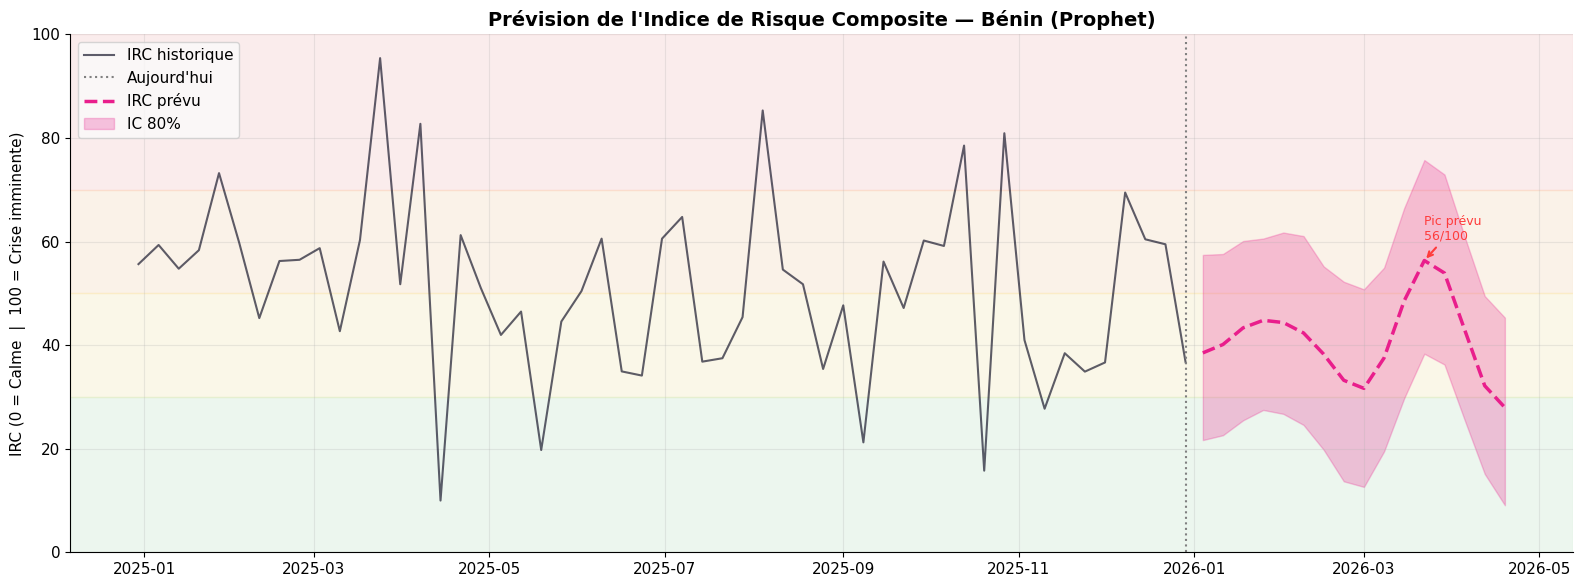

In [27]:
# --- Visualisation Prophet ---
fig, ax = plt.subplots(figsize=(16, 6))

# Zones de risque
for ymin, ymax, color, label in [
    (70, 100, COLORS['danger'],  'CRITIQUE'),
    (50,  70, COLORS['warning'], 'ÉLEVÉ'),
    (30,  50, 'gold',            'MODÉRÉ'),
    (0,   30, COLORS['safe'],    'FAIBLE')
]:
    ax.axhspan(ymin, ymax, alpha=0.07, color=color)

# Historique
ax.plot(prophet_df['ds'], prophet_df['y'],
        color=COLORS['dark'], lw=1.5, alpha=0.7, label='IRC historique')

# Séparateur
ax.axvline(last_date, color='grey', ls=':', lw=1.5, label='Aujourd\'hui')

# Prévision + intervalle
ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color=COLORS['primary'], lw=2.5, ls='--', label='IRC prévu')
ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'],
                forecast_future['yhat_upper'],
                alpha=0.25, color=COLORS['primary'], label='IC 80%')

# Annotation du pic prévu
idx_max = forecast_future['yhat'].idxmax()
ax.annotate(
    f"Pic prévu\n{forecast_future.loc[idx_max,'yhat']:.0f}/100",
    xy=(forecast_future.loc[idx_max,'ds'], forecast_future.loc[idx_max,'yhat']),
    xytext=(0, 15), textcoords='offset points',
    fontsize=9, color=COLORS['danger'],
    arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5)
)

ax.set_ylim(0, 100)
ax.set_title('Prévision de l\'Indice de Risque Composite — Bénin (Prophet)', fontsize=14, fontweight='bold')
ax.set_ylabel('IRC (0 = Calme  |  100 = Crise imminente)')
ax.legend(loc='upper left')
plt.tight_layout()
# plt.savefig(OUTPUTS / 'prevision_irc_prophet.png', dpi=150, bbox_inches='tight')
plt.show()

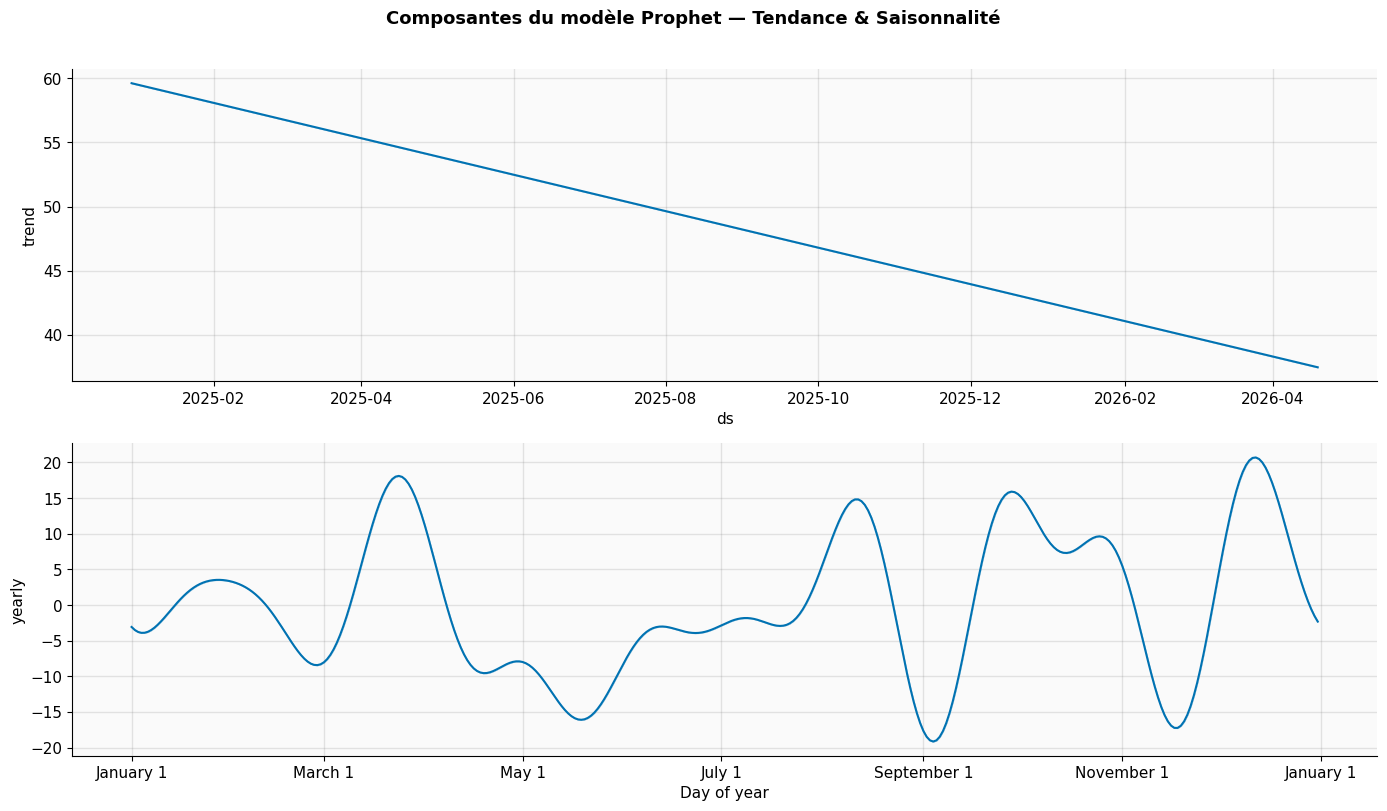

In [29]:
# --- Décomposition Prophet : tendance + saisonnalité ---
fig = prophet_model.plot_components(forecast)
fig.set_size_inches(14, 8)
plt.suptitle('Composantes du modèle Prophet — Tendance & Saisonnalité', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(OUTPUTS / 'prophet_composantes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modèle de Prédiction à Horizon Décalé (Lag Features)

> On entraîne un modèle XGBoost qui prédit **si la semaine N+1 (ou N+4) sera à haut risque**
> en se basant sur les signaux observés jusqu'à la semaine N.

In [30]:
# --- Construction des features avec lags ---
wk = weekly.copy().reset_index(drop=True)

# Features de base
BASE_FEATS = ['IRC', 'ConflictRate', 'Tone_moy', 'Goldstein_moy', 'EventCount', 'TotalArticles']

# Lags 1, 2, 3, 4 semaines
for feat in BASE_FEATS:
    for lag in range(1, 5):
        wk[f'{feat}_lag{lag}'] = wk[feat].shift(lag)

# Moyennes mobiles
for feat in ['IRC', 'ConflictRate', 'Tone_moy']:
    wk[f'{feat}_ma4']  = wk[feat].rolling(4).mean()
    wk[f'{feat}_ma8']  = wk[feat].rolling(8).mean()
    wk[f'{feat}_std4'] = wk[feat].rolling(4).std()

# Tendance récente (différence)
wk['IRC_delta1'] = wk['IRC'].diff(1)
wk['IRC_delta4'] = wk['IRC'].diff(4)

# Saisonnalité
wk['month'] = wk['date_dt'].dt.month
wk['quarter'] = wk['date_dt'].dt.quarter

# CIBLES : prédire le risque dans 1 et 4 semaines
wk['target_1w']  = (wk['IRC'].shift(-1) >= 50).astype(int)   # Risque élevé la semaine prochaine
wk['target_4w']  = (wk['IRC'].shift(-4) >= 50).astype(int)   # Risque élevé dans 4 semaines
wk['irc_next1w'] = wk['IRC'].shift(-1)                        # Valeur exacte +1 semaine

wk = wk.dropna().reset_index(drop=True)

LAG_FEATS = [c for c in wk.columns if any(c.endswith(s) for s in
             ['_lag1','_lag2','_lag3','_lag4','_ma4','_ma8','_std4','_delta1','_delta4']) or c in ['month','quarter']]


In [31]:
# --- Entraînement avec validation temporelle (TimeSeriesSplit) ---
tscv = TimeSeriesSplit(n_splits=5)
results_horizon = {}

for horizon, target_col in [('1 semaine', 'target_1w'), ('4 semaines', 'target_4w')]:
    X = wk[LAG_FEATS]
    y = wk[target_col]

    # Split temporel (80/20)
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Modèle
    model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss'
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    results_horizon[horizon] = {
        'model': model, 'X_test': X_test, 'y_test': y_test,
        'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc
    }

    print(f'\n🎯 Horizon : {horizon}')
    print(f'   AUC-ROC : {auc:.3f}')
    print(classification_report(y_test, y_pred, target_names=['Calme/Modéré','Élevé/Critique']))

print('\n✅ Modèles entraînés pour les deux horizons')


🎯 Horizon : 1 semaine
   AUC-ROC : 0.444
                precision    recall  f1-score   support

  Calme/Modéré       0.60      0.50      0.55         6
Élevé/Critique       0.25      0.33      0.29         3

      accuracy                           0.44         9
     macro avg       0.42      0.42      0.42         9
  weighted avg       0.48      0.44      0.46         9


🎯 Horizon : 4 semaines
   AUC-ROC : 0.611
                precision    recall  f1-score   support

  Calme/Modéré       0.80      0.67      0.73         6
Élevé/Critique       0.50      0.67      0.57         3

      accuracy                           0.67         9
     macro avg       0.65      0.67      0.65         9
  weighted avg       0.70      0.67      0.68         9


✅ Modèles entraînés pour les deux horizons


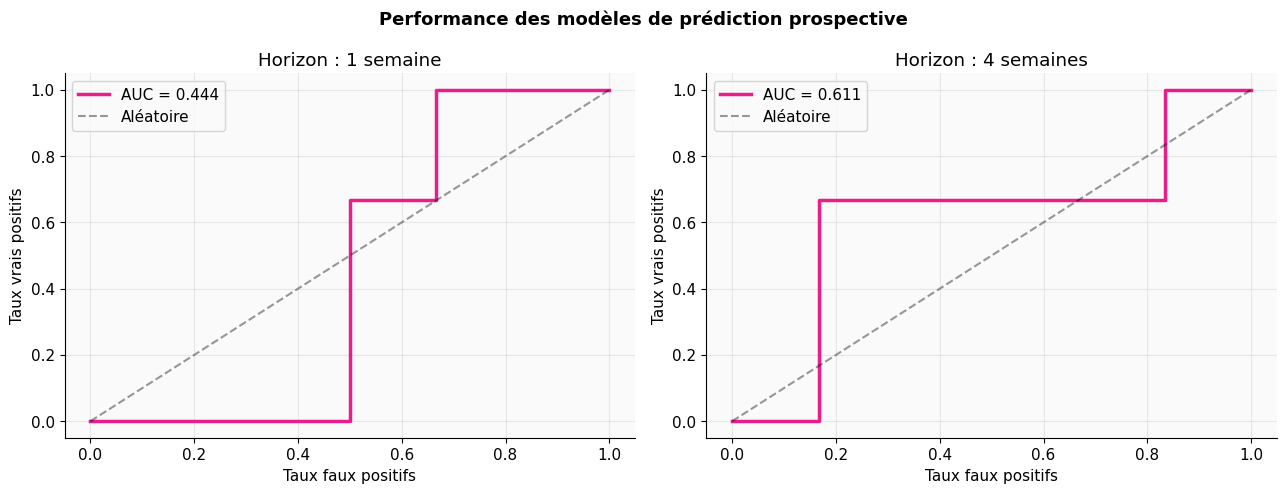

In [32]:
# --- Courbes ROC ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance des modèles de prédiction prospective', fontsize=13, fontweight='bold')

for ax, (horizon, res) in zip(axes, results_horizon.items()):
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_proba'])
    ax.plot(fpr, tpr, color=COLORS['primary'], lw=2.5, label=f'AUC = {res["auc"]:.3f}')
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Aléatoire')
    ax.set_xlabel('Taux faux positifs'); ax.set_ylabel('Taux vrais positifs')
    ax.set_title(f'Horizon : {horizon}')
    ax.legend()

plt.tight_layout()
# plt.savefig(OUTPUTS / 'roc_horizons.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Explicabilité — Pourquoi le modèle prédit un risque ? (SHAP)

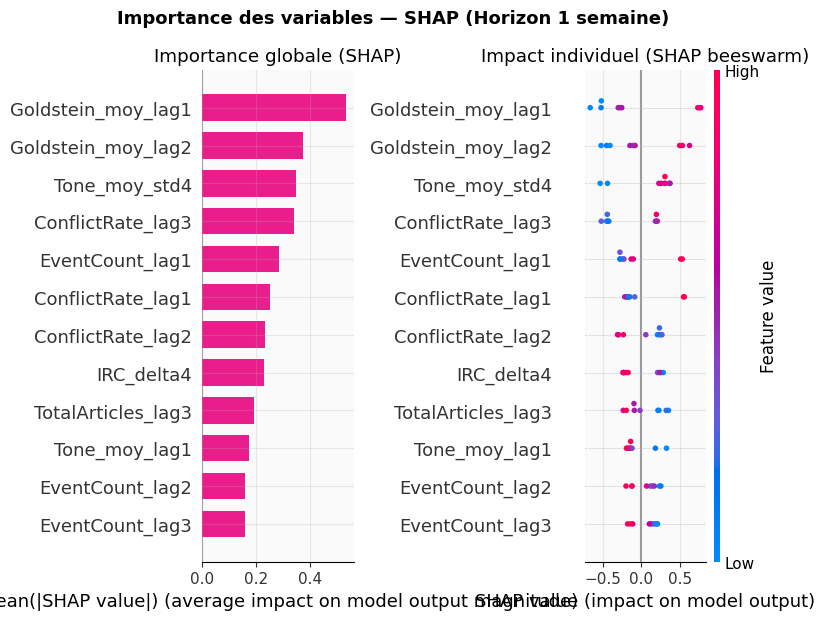

In [33]:
# --- SHAP sur le modèle 1 semaine ---
res_1w = results_horizon['1 semaine']
explainer = shap.TreeExplainer(res_1w['model'])
shap_values = explainer.shap_values(res_1w['X_test'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importance des variables — SHAP (Horizon 1 semaine)', fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, res_1w['X_test'], plot_type='bar',
                  max_display=12, show=False, color=COLORS['primary'])
axes[0].set_title('Importance globale (SHAP)')

plt.sca(axes[1])
shap.summary_plot(shap_values, res_1w['X_test'],
                  max_display=12, show=False)
axes[1].set_title('Impact individuel (SHAP beeswarm)')

plt.tight_layout()
# plt.savefig(OUTPUTS / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Dashboard Résumé Interactif (Plotly)

In [40]:
# --- Dashboard interactif Plotly ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'IRC Historique + Prévision',
        'Probabilité de crise — Horizon 1 semaine (test)',
        'Scénarios What-If',
        'Décomposition de l\'IRC actuel'
    ),
    specs=[[{'colspan':2}, None], [{}, {}]],
    row_heights=[0.55, 0.45]
)

# 1. IRC + prévision
fig.add_trace(go.Scatter(
    x=weekly['date_dt'], y=weekly['IRC'],
    name='IRC historique', line=dict(color='#1A1A2E', width=1.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=forecast_future['ds'], y=forecast_future['yhat'],
    name='IRC prévu', line=dict(color='#E91E8C', width=2.5, dash='dash')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=pd.concat([forecast_future['ds'], forecast_future['ds'].iloc[::-1]]),
    y=pd.concat([forecast_future['yhat_upper'], forecast_future['yhat_lower'].iloc[::-1]]),
    fill='toself', fillcolor='rgba(233,30,140,0.15)',
    line=dict(color='rgba(255,255,255,0)'), name='IC 80%'
), row=1, col=1)

# 2. Probabilités sur test
res_1w = results_horizon['1 semaine']
test_idx = wk.iloc[int(len(wk)*0.8):]['date_dt']
fig.add_trace(go.Scatter(
    x=test_idx, y=res_1w['y_proba'],
    name='P(risque élevé)', line=dict(color='#FF6B35', width=2)
), row=2, col=1)
fig.add_hline(y=0.5, line_dash='dot', line_color='grey', row=2, col=1)

# 3. Scénarios
fig.add_trace(go.Bar(
    x=probas, y=noms, orientation='h',
    marker_color=colors_sc, name='Scénarios'
), row=2, col=2)

fig.update_layout(
    height=650,
    title_text='🇧🇯 Dashboard Prédictif — Risques Socio-Politiques au Bénin',
    title_font_size=16,
    showlegend=True,
    template='plotly_white'
)

# fig.write_html(str(OUTPUTS / 'dashboard_prevision.html'))
fig.show()